<a href="https://colab.research.google.com/github/Noura2026-prog/rapport-stage-kmeans/blob/main/K_Means_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# H2 — TABLEAU DE BORD K-MEANS
# Détection autonome : normal / dérive modérée / dérive critique
# ============================================================

from google.colab import files
uploaded = files.upload()

!pip install openpyxl -q

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name=4, header=2)
df = df.dropna(subset=["Mois"]).reset_index(drop=True)

kpi_cols = ["KPI1","KPI2","KPI3","KPI4","KPI5","KPI6","KPI7","KPI8"]

df = df[["Mois"] + kpi_cols].copy()

for kpi in kpi_cols:
    df[kpi] = pd.to_numeric(df[kpi], errors="coerce")

df = df.dropna().reset_index(drop=True)

kpi_names = {
    "KPI1": "Coût énergie/t",
    "KPI2": "Taux conso. budgétaire",
    "KPI3": "Écart coût soufre",
    "KPI4": "Coût maintenance",
    "KPI5": "Coût MO/t",
    "KPI6": "Dépassement charges fixes",
    "KPI7": "Coût logistique/t",
    "KPI8": "Écart coût standard"
}

BASELINE_END = 8   # Jan-24 à Aoû-24

print("Données chargées :", len(df), "mois")
print("Baseline :", df["Mois"].iloc[0], "→", df["Mois"].iloc[BASELINE_END-1])
print("Surveillance :", df["Mois"].iloc[BASELINE_END], "→", df["Mois"].iloc[-1])

Saving OCP_H2_SeuilFixe.xlsx to OCP_H2_SeuilFixe.xlsx
Données chargées : 24 mois
Baseline : Jan-24 → Aoû-24
Surveillance : Sep-24 → Déc-25


In [ ]:
# ============================================================
# 2. NORMALISATION SUR LA BASELINE UNIQUEMENT
# ============================================================

scaler = StandardScaler()

X_base = scaler.fit_transform(df.iloc[:BASELINE_END][kpi_cols])
X_full = scaler.transform(df[kpi_cols])

print("[OK] Normalisation faite sur la baseline uniquement.")

[OK] Normalisation faite sur la baseline uniquement.


In [ ]:
# ============================================================
# 3. K-MEANS PAR KPI — K=3
# Normal / dérive modérée / dérive critique
# ============================================================

severity_df = pd.DataFrame({"Mois": df["Mois"]})
score_df = pd.DataFrame({"Mois": df["Mois"]})

cluster_info = {}

for j, kpi in enumerate(kpi_cols):

    # Série d'un KPI normalisée
    X_kpi = X_full[:, j].reshape(-1, 1)

    # K-Means K=3 : trois zones de comportement
    km = KMeans(n_clusters=3, random_state=42, n_init=30)
    labels = km.fit_predict(X_kpi)

    centers = km.cluster_centers_.flatten()

    # Cluster historique dominant sur la baseline = comportement normal
    baseline_labels = labels[:BASELINE_END]
    normal_cluster = pd.Series(baseline_labels).mode()[0]

    # Distance de chaque cluster au cluster normal
    dist_clusters = {
        c: abs(centers[c] - centers[normal_cluster])
        for c in range(3)
    }

    # Classement des clusters : normal < modéré < critique
    ordered_clusters = sorted(dist_clusters, key=dist_clusters.get)

    severity_map = {
        ordered_clusters[0]: 0,  # normal
        ordered_clusters[1]: 1,  # dérive modérée
        ordered_clusters[2]: 2   # dérive critique
    }

    # Sévérité mensuelle
    severities = np.array([severity_map[label] for label in labels])

    # Score de dérive = distance entre cluster courant et cluster normal historique
    scores = np.array([dist_clusters[label] for label in labels])

    # Pas d'alerte affichée pendant la calibration
    severities_dashboard = severities.copy()
    severities_dashboard[:BASELINE_END] = 0

    severity_df[kpi] = severities_dashboard
    score_df[kpi] = scores

    cluster_info[kpi] = {
        "model": km,
        "centers": centers,
        "normal_cluster": normal_cluster,
        "dist_clusters": dist_clusters
    }

print("[OK] K-Means appliqué par KPI avec K=3.")

[OK] K-Means appliqué par KPI avec K=3.


In [ ]:
# ============================================================
# 4. CONSTRUCTION DU TABLEAU DE BORD K-MEANS
# ============================================================

rows = []

for i in range(len(df)):

    if i < BASELINE_END:
        phase = "CALIBRATION"
    else:
        phase = "SURVEILLANCE"

    kpis_moderes = []
    kpis_critiques = []

    for kpi in kpi_cols:
        sev = severity_df.loc[i, kpi]

        if phase == "SURVEILLANCE":
            if sev == 1:
                kpis_moderes.append(kpi)
            elif sev == 2:
                kpis_critiques.append(kpi)

    if phase == "CALIBRATION":
        statut_global = "CALIBRATION"
    elif len(kpis_critiques) > 0:
        statut_global = "DÉRIVE CRITIQUE"
    elif len(kpis_moderes) > 0:
        statut_global = "DÉRIVE MODÉRÉE"
    else:
        statut_global = "NORMAL"

    nb_kpis_derive = len(kpis_moderes) + len(kpis_critiques)

    # KPI principal = KPI avec score de dérive le plus élevé
    if nb_kpis_derive > 0:
        scores_i = score_df.loc[i, kpi_cols]
        kpi_principal = scores_i.idxmax()
        score_global = scores_i.max()
    else:
        kpi_principal = "-"
        score_global = 0

    rows.append({
        "Idx": i,
        "Mois": df.loc[i, "Mois"],
        "Phase": phase,
        "Statut_global": statut_global,
        "Nb_KPIs_en_derive": nb_kpis_derive,
        "KPIs_modérés": ", ".join(kpis_moderes) if kpis_moderes else "-",
        "KPIs_critiques": ", ".join(kpis_critiques) if kpis_critiques else "-",
        "KPI_principal": kpi_principal,
        "Score_global": score_global
    })

tdb = pd.DataFrame(rows)

print(tdb.to_string(index=False))

 Idx   Mois        Phase   Statut_global  Nb_KPIs_en_derive                       KPIs_modérés         KPIs_critiques KPI_principal  Score_global
   0 Jan-24  CALIBRATION     CALIBRATION                  0                                  -                      -             -      0.000000
   1 Fév-24  CALIBRATION     CALIBRATION                  0                                  -                      -             -      0.000000
   2 Mar-24  CALIBRATION     CALIBRATION                  0                                  -                      -             -      0.000000
   3 Avr-24  CALIBRATION     CALIBRATION                  0                                  -                      -             -      0.000000
   4 Mai-24  CALIBRATION     CALIBRATION                  0                                  -                      -             -      0.000000
   5 Jun-24  CALIBRATION     CALIBRATION                  0                                  -                      -       

In [ ]:
# ============================================================
# 5. CALCUL SIMPLE DE LA LATENCE
# Utilisé uniquement pour évaluer H2
# ============================================================

# Début réel des dérives injectées
# Ces informations ne sont PAS utilisées par K-Means
debut_derives = {
    "KPI3": 8,    # Sep-24
    "KPI1": 12,   # Jan-25
    "KPI8": 13,   # Fév-25
    "KPI6": 15    # Avr-25
}

latence_rows = []

for kpi, debut_idx in debut_derives.items():

    # Première fois où le KPI sort de la zone normale
    detections = severity_df[
        (severity_df.index >= debut_idx) &
        (severity_df[kpi] > 0)
    ]

    if len(detections) > 0:
        first_idx = detections.index[0]
        first_mois = df.loc[first_idx, "Mois"]
        latence = first_idx - debut_idx
        statut = "Détecté"
    else:
        first_idx = None
        first_mois = "-"
        latence = "-"
        statut = "Non détecté"

    latence_rows.append({
        "KPI": kpi,
        "Nom": kpi_names[kpi],
        "Début dérive": df.loc[debut_idx, "Mois"],
        "Première détection K-Means": first_mois,
        "Latence_mois": latence,
        "Statut": statut
    })

df_latence = pd.DataFrame(latence_rows)

print(df_latence.to_string(index=False))

latences_valides = [
    x for x in df_latence["Latence_mois"]
    if isinstance(x, (int, float, np.integer, np.floating))
]

print("\nLatence moyenne K-Means :", round(np.mean(latences_valides), 2), "mois")

 KPI                       Nom Début dérive Première détection K-Means  Latence_mois  Statut
KPI3         Écart coût soufre       Sep-24                     Sep-24             0 Détecté
KPI1            Coût énergie/t       Jan-25                     Fév-25             1 Détecté
KPI8       Écart coût standard       Fév-25                     Mar-25             1 Détecté
KPI6 Dépassement charges fixes       Avr-25                     Avr-25             0 Détecté

Latence moyenne K-Means : 0.5 mois


In [ ]:
# ============================================================
# 6. MÉTRIQUES H2
# ============================================================

total_injectes = len(debut_derives)

detectes = df_latence[df_latence["Statut"] == "Détecté"]["KPI"].tolist()
nb_detectes = len(detectes)

# Couverture : chaque KPI reçoit une zone et un score K-Means
coverage = len(kpi_cols) / len(kpi_cols) * 100

print("=== MÉTRIQUES H2 — K-MEANS ===")
print("KPIs injectés :", list(debut_derives.keys()))
print("KPIs détectés :", detectes)
print("Nombre détecté :", nb_detectes, "/", total_injectes)
print("Taux de détection :", round(nb_detectes / total_injectes * 100, 1), "%")
print("Latence moyenne :", round(np.mean(latences_valides), 2), "mois")
print("Taux de couverture du pilotage :", round(coverage, 1), "%")

=== MÉTRIQUES H2 — K-MEANS ===
KPIs injectés : ['KPI3', 'KPI1', 'KPI8', 'KPI6']
KPIs détectés : ['KPI3', 'KPI1', 'KPI8', 'KPI6']
Nombre détecté : 4 / 4
Taux de détection : 100.0 %
Latence moyenne : 0.5 mois
Taux de couverture du pilotage : 100.0 %


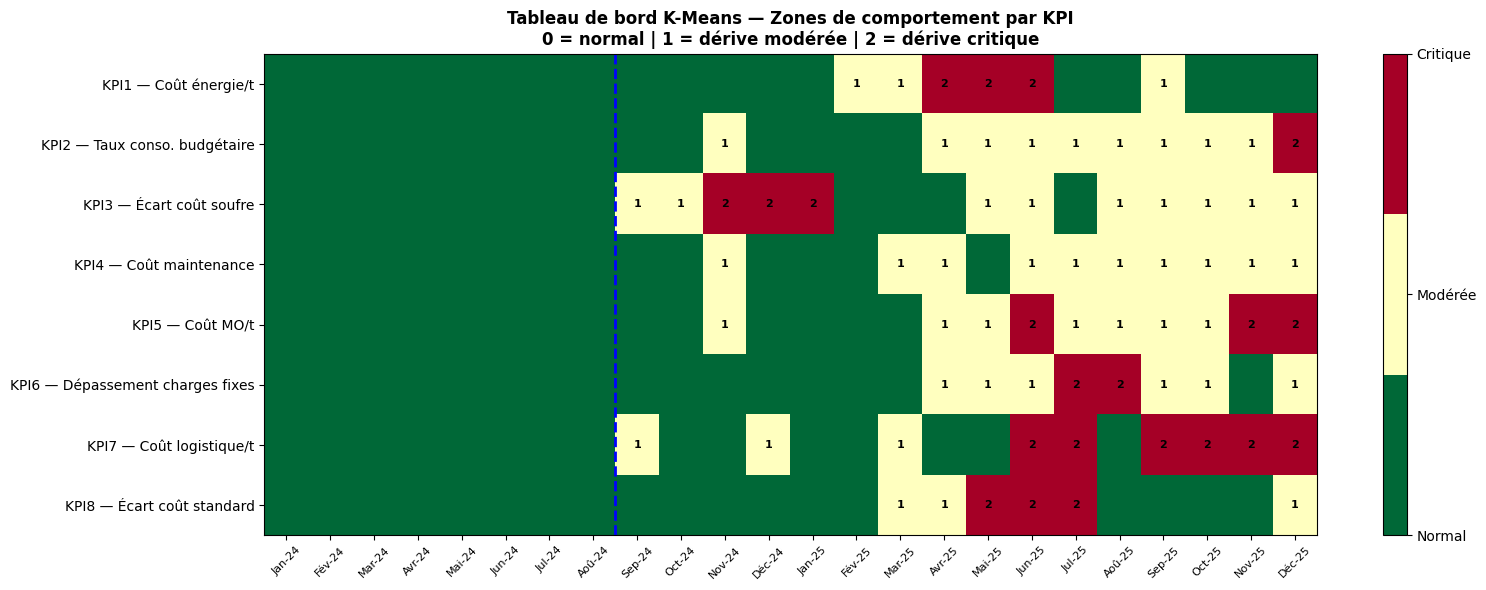

In [ ]:
# ============================================================
# 7. TABLEAU DE BORD VISUEL — HEATMAP DES ZONES K-MEANS
# ============================================================

zone_matrix = severity_df[kpi_cols].T.values

fig, ax = plt.subplots(figsize=(16, 6))

cmap = plt.cm.get_cmap("RdYlGn_r", 3)

im = ax.imshow(zone_matrix, aspect="auto", cmap=cmap, vmin=0, vmax=2)

ax.set_title(
    "Tableau de bord K-Means — Zones de comportement par KPI\n"
    "0 = normal | 1 = dérive modérée | 2 = dérive critique",
    fontsize=12,
    fontweight="bold"
)

ax.set_yticks(range(len(kpi_cols)))
ax.set_yticklabels([f"{kpi} — {kpi_names[kpi]}" for kpi in kpi_cols])

ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["Mois"], rotation=45, fontsize=8)

# Ligne séparation baseline / surveillance
ax.axvline(BASELINE_END - 0.5, color="blue", linestyle="--", linewidth=2)

# Afficher les valeurs dans les cellules
for i in range(len(kpi_cols)):
    for j in range(len(df)):
        val = zone_matrix[i, j]
        if j >= BASELINE_END and val > 0:
            ax.text(j, i, int(val), ha="center", va="center",
                    color="black", fontsize=8, fontweight="bold")

cbar = plt.colorbar(im, ticks=[0,1,2])
cbar.ax.set_yticklabels(["Normal", "Modérée", "Critique"])

plt.tight_layout()
plt.savefig("TDB_KMeans_Heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

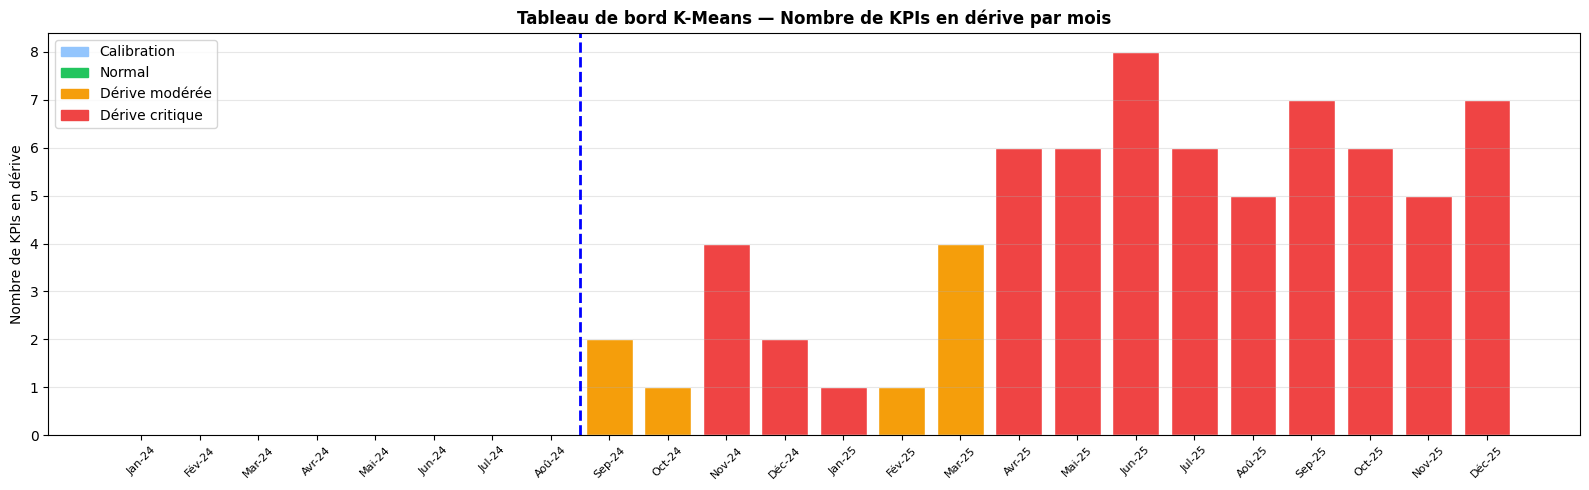

In [ ]:
# ============================================================
# 8. TABLEAU DE BORD VISUEL — STATUT GLOBAL MENSUEL
# ============================================================

couleurs = {
    "CALIBRATION": "#93c5fd",
    "NORMAL": "#22c55e",
    "DÉRIVE MODÉRÉE": "#f59e0b",
    "DÉRIVE CRITIQUE": "#ef4444"
}

fig, ax = plt.subplots(figsize=(16, 5))

for i in range(len(tdb)):
    ax.bar(
        tdb.loc[i, "Mois"],
        tdb.loc[i, "Nb_KPIs_en_derive"],
        color=couleurs[tdb.loc[i, "Statut_global"]],
        edgecolor="white"
    )

ax.axvline(BASELINE_END - 0.5, color="blue", linestyle="--", linewidth=2)

ax.set_title(
    "Tableau de bord K-Means — Nombre de KPIs en dérive par mois",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel("Nombre de KPIs en dérive")
ax.set_xticks(range(len(tdb)))
ax.set_xticklabels(tdb["Mois"], rotation=45, fontsize=8)

legend_items = [
    mpatches.Patch(color="#93c5fd", label="Calibration"),
    mpatches.Patch(color="#22c55e", label="Normal"),
    mpatches.Patch(color="#f59e0b", label="Dérive modérée"),
    mpatches.Patch(color="#ef4444", label="Dérive critique")
]

ax.legend(handles=legend_items)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("TDB_KMeans_Global.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 9. EXPORT TABLEAU DE BORD
# ============================================================

with pd.ExcelWriter("Tableau_de_bord_KMeans_H2.xlsx") as writer:
    df.to_excel(writer, sheet_name="Données", index=False)
    tdb.to_excel(writer, sheet_name="TDB_Global", index=False)
    severity_df.to_excel(writer, sheet_name="Zones_KMeans", index=False)
    score_df.to_excel(writer, sheet_name="Scores_KMeans", index=False)
    df_latence.to_excel(writer, sheet_name="Latence_H2", index=False)

files.download("Tableau_de_bord_KMeans_H2.xlsx")
files.download("TDB_KMeans_Heatmap.png")
files.download("TDB_KMeans_Global.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  COMPARAISON H2 — TABLEAU DE BORD TRADITIONNEL vs AUGMENTÉ
  OCP Jorf Lasfar | UP-AP | Jan 2024 – Déc 2025

KPI    |  Dérive  |    SEUIL FIXE ±10%     |     K-MEANS (K=3)     
       |  début   | 1ère alerte   Latence  | 1ère alerte   Latence 
----------------------------------------------------------------------
KPI3   |  Sep-24  | Non détecté       ∞ | Sep-24           0m
KPI1   |  Jan-25  | Mai-25           4m | Fév-25           1m
KPI8   |  Fév-25  | Non détecté       ∞ | Mar-25           1m
KPI6   |  Avr-25  | Non détecté       ∞ | Avr-25           0m
----------------------------------------------------------------------

Métrique                            |   Seuil Fixe    |     K-Means    
----------------------------------------------------------------------
KPIs détectés / 4 injectés          |       1/4       |       4/4      
Taux de détection                   |       25%       |      100%      
Latence moyenne de détection        |    4.0 mois     |    0.5 mois    
Taux 

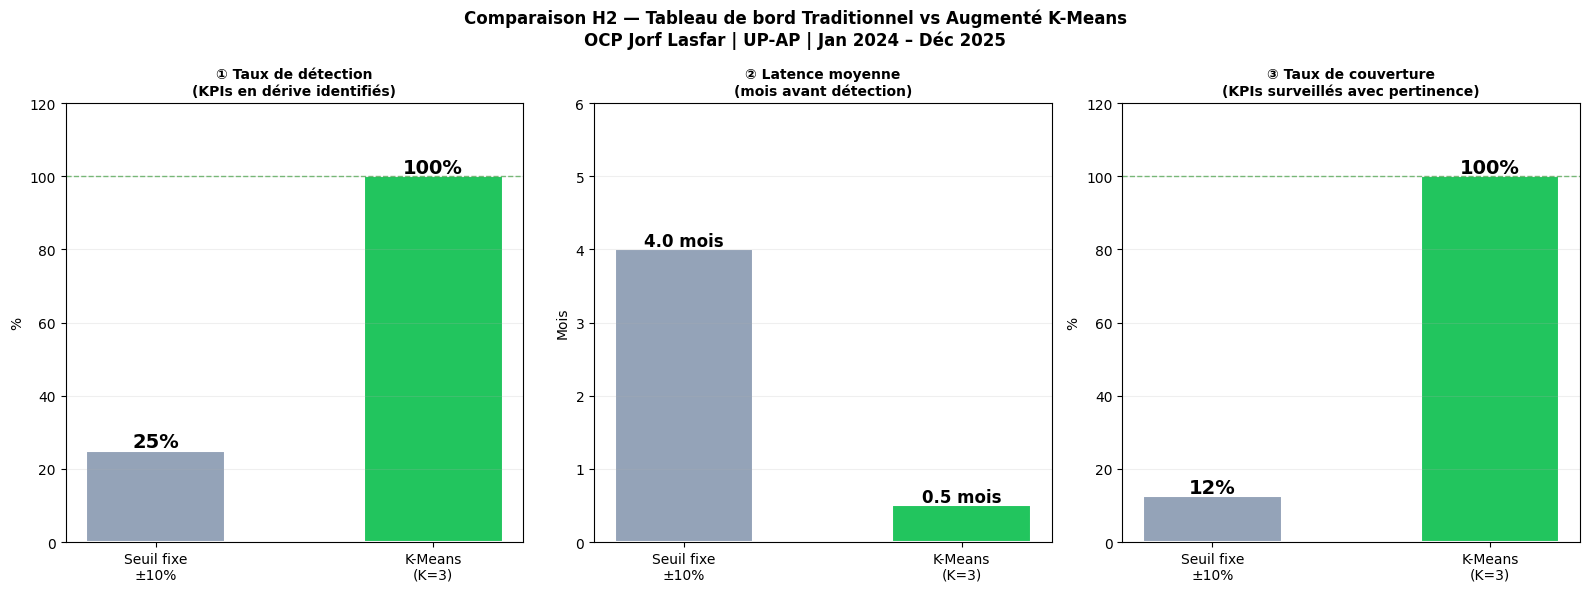

[OK] Graphique comparaison sauvegardé.


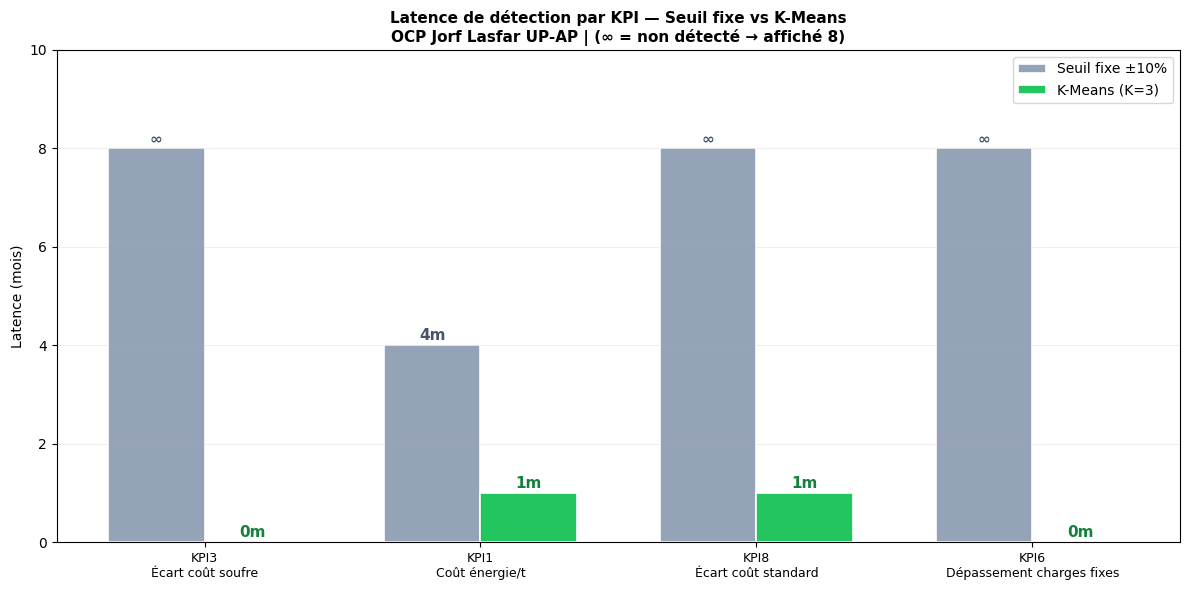

[OK] Graphique latences comparées sauvegardé.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[OK] Comparaison H2 exportée.


In [ ]:
# ============================================================
# COMPARAISON H2 — SEUIL FIXE vs K-MEANS
# ============================================================

# ── Métriques seuil fixe (issues de votre simulation) ──
bases_sf = {
    'KPI1': 52.0, 'KPI2': 0.80, 'KPI3': 0.012, 'KPI4': 3.20,
    'KPI5': 28.0, 'KPI6': 0.035,'KPI7': 22.0,  'KPI8': 0.018
}
SEUIL_FIXE = 0.10  # ±10%

debut_derives = {
    'KPI3': 8,   # Sep-24
    'KPI1': 12,  # Jan-25
    'KPI8': 13,  # Fév-25
    'KPI6': 15   # Avr-25
}

# Calcul détection seuil fixe
sf_resultats = {}
for kpi, debut_idx in debut_derives.items():
    base = bases_sf[kpi]
    premier_idx_sf = None
    for i in range(BASELINE_END, len(df)):
        ecart = abs(df[kpi].iloc[i] - base) / base
        if ecart > SEUIL_FIXE:
            premier_idx_sf = i
            break
    if premier_idx_sf is not None:
        latence_sf = premier_idx_sf - debut_idx
        mois_sf    = df['Mois'].iloc[premier_idx_sf]
        detecte_sf = True
    else:
        latence_sf = None
        mois_sf    = 'Non détecté'
        detecte_sf = False

    sf_resultats[kpi] = {
        'detecte' : detecte_sf,
        'mois'    : mois_sf,
        'latence' : latence_sf
    }

# Métriques seuil fixe
sf_detectes = [k for k, v in sf_resultats.items() if v['detecte']]
sf_latences  = [v['latence'] for v in sf_resultats.values()
                if v['latence'] is not None]
sf_taux_det  = len(sf_detectes) / len(debut_derives) * 100
sf_lat_moy   = np.mean(sf_latences) if sf_latences else None
sf_couverture= len(sf_detectes) / len(kpi_cols) * 100

# Métriques K-Means (de votre code)
km_detectes   = df_latence[df_latence['Statut']=='Détecté']['KPI'].tolist()
km_taux_det   = len(km_detectes) / len(debut_derives) * 100
km_lat_moy    = round(np.mean(latences_valides), 2)
km_couverture = len(kpi_cols) / len(kpi_cols) * 100

# ── Tableau comparatif texte ──
print("=" * 70)
print("  COMPARAISON H2 — TABLEAU DE BORD TRADITIONNEL vs AUGMENTÉ")
print("  OCP Jorf Lasfar | UP-AP | Jan 2024 – Déc 2025")
print("=" * 70)
print(f"\n{'KPI':<6} | {'Dérive':^8} | "
      f"{'SEUIL FIXE ±10%':^22} | {'K-MEANS (K=3)':^22}")
print(f"{'':^6} | {'début':^8} | "
      f"{'1ère alerte':^12} {'Latence':^9} | "
      f"{'1ère alerte':^12} {'Latence':^9}")
print("-" * 70)

for kpi, debut_idx in debut_derives.items():
    debut_mois = df['Mois'].iloc[debut_idx]
    sf = sf_resultats[kpi]
    km = df_latence[df_latence['KPI'] == kpi].iloc[0]

    sf_str  = f"{str(sf['mois']):<12} {str(sf['latence'])+'m' if sf['latence'] is not None else '∞':>6}"
    km_str  = f"{str(km['Première détection K-Means']):<12} {str(km['Latence_mois'])+'m':>6}"

    print(f"{kpi:<6} | {str(debut_mois):^8} | {sf_str} | {km_str}")

print("-" * 70)
print(f"\n{'Métrique':<35} | {'Seuil Fixe':^15} | {'K-Means':^15}")
print("-" * 70)
print(f"{'KPIs détectés / 4 injectés':<35} | "
      f"{f'{len(sf_detectes)}/4':^15} | "
      f"{f'{len(km_detectes)}/4':^15}")
print(f"{'Taux de détection':<35} | "
      f"{f'{sf_taux_det:.0f}%':^15} | "
      f"{f'{km_taux_det:.0f}%':^15}")
print(f"{'Latence moyenne de détection':<35} | "
      f"{f'{sf_lat_moy:.1f} mois' if sf_lat_moy else 'N/A':^15} | "
      f"{f'{km_lat_moy} mois':^15}")
print(f"{'Taux de couverture du pilotage':<35} | "
      f"{f'{sf_couverture:.0f}%':^15} | "
      f"{f'{km_couverture:.0f}%':^15}")
print("=" * 70)

gain_det = km_taux_det - sf_taux_det
gain_lat = sf_lat_moy - km_lat_moy if sf_lat_moy else None
print(f"\n  Gain détection  : +{gain_det:.0f}% en faveur du K-Means")
if gain_lat:
    print(f"  Gain latence    : -{gain_lat:.1f} mois en faveur du K-Means")
print(f"  H2 {'✅ VALIDÉE' if km_taux_det > sf_taux_det else '⚠️ À VÉRIFIER'}")

# ============================================================
# GRAPHIQUE COMPARAISON — 3 métriques côte à côte
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Comparaison H2 — Tableau de bord Traditionnel vs Augmenté K-Means\n'
    'OCP Jorf Lasfar | UP-AP | Jan 2024 – Déc 2025',
    fontsize=12, fontweight='bold'
)

C_SF = '#94a3b8'   # gris
C_KM = '#22c55e'   # vert

# ── Graphique 1 : Taux de détection ──
ax1 = axes[0]
vals = [sf_taux_det, km_taux_det]
bars = ax1.bar(['Seuil fixe\n±10%', 'K-Means\n(K=3)'],
               vals, color=[C_SF, C_KM],
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.0f}%', ha='center',
             fontsize=14, fontweight='bold')
ax1.set_title('① Taux de détection\n(KPIs en dérive identifiés)',
              fontsize=10, fontweight='bold')
ax1.set_ylabel('%')
ax1.set_ylim(0, 120)
ax1.axhline(y=100, color='green', linestyle='--',
            linewidth=1, alpha=0.5)
ax1.grid(alpha=0.2, axis='y')
ax1.tick_params(labelsize=10)

# ── Graphique 2 : Latence moyenne ──
ax2 = axes[1]
lat_sf_plot = sf_lat_moy if sf_lat_moy else 0
lat_km_plot = km_lat_moy
bars2 = ax2.bar(['Seuil fixe\n±10%', 'K-Means\n(K=3)'],
                [lat_sf_plot, lat_km_plot],
                color=[C_SF, C_KM],
                edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars2, [lat_sf_plot, lat_km_plot]):
    label = f'{val:.1f} mois' if val > 0 else 'Non\ndétecté'
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             label, ha='center',
             fontsize=12, fontweight='bold')
ax2.set_title('② Latence moyenne\n(mois avant détection)',
              fontsize=10, fontweight='bold')
ax2.set_ylabel('Mois')
ax2.set_ylim(0, max(lat_sf_plot, lat_km_plot) + 2)
ax2.grid(alpha=0.2, axis='y')
ax2.tick_params(labelsize=10)

# ── Graphique 3 : Couverture ──
ax3 = axes[2]
vals3 = [sf_couverture, km_couverture]
bars3 = ax3.bar(['Seuil fixe\n±10%', 'K-Means\n(K=3)'],
                vals3, color=[C_SF, C_KM],
                edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars3, vals3):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.0f}%', ha='center',
             fontsize=14, fontweight='bold')
ax3.set_title('③ Taux de couverture\n(KPIs surveillés avec pertinence)',
              fontsize=10, fontweight='bold')
ax3.set_ylabel('%')
ax3.set_ylim(0, 120)
ax3.axhline(y=100, color='green', linestyle='--',
            linewidth=1, alpha=0.5)
ax3.grid(alpha=0.2, axis='y')
ax3.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("H2_Comparaison_finale.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Graphique comparaison sauvegardé.")

# ============================================================
# GRAPHIQUE — LATENCE PAR KPI (côte à côte)
# ============================================================
kpis_list = list(debut_derives.keys())
x         = np.arange(len(kpis_list))
w         = 0.35

sf_lats_plot = [sf_resultats[k]['latence'] if sf_resultats[k]['latence']
                is not None else 8 for k in kpis_list]
km_lats_plot = [int(df_latence[df_latence['KPI']==k]['Latence_mois'].values[0])
                if df_latence[df_latence['KPI']==k]['Statut'].values[0]=='Détecté'
                else 8 for k in kpis_list]

fig, ax = plt.subplots(figsize=(12, 6))

b1 = ax.bar(x - w/2, sf_lats_plot, w, label='Seuil fixe ±10%',
            color=C_SF, edgecolor='white', linewidth=1.2)
b2 = ax.bar(x + w/2, km_lats_plot, w, label='K-Means (K=3)',
            color=C_KM, edgecolor='white', linewidth=1.2)

for bar, val in zip(b1, sf_lats_plot):
    lbl = '∞' if val == 8 else f'{val}m'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            lbl, ha='center', fontsize=11,
            fontweight='bold', color='#475569')

for bar, val in zip(b2, km_lats_plot):
    lbl = '∞' if val == 8 else f'{val}m'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            lbl, ha='center', fontsize=11,
            fontweight='bold', color='#15803d')

ax.set_title(
    'Latence de détection par KPI — Seuil fixe vs K-Means\n'
    'OCP Jorf Lasfar UP-AP | (∞ = non détecté → affiché 8)',
    fontsize=11, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{k}\n{kpi_names[k]}' for k in kpis_list],
    fontsize=9
)
ax.set_ylabel('Latence (mois)', fontsize=10)
ax.set_ylim(0, 10)
ax.legend(fontsize=10)
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig("H2_Latences_comparees.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Graphique latences comparées sauvegardé.")

# ============================================================
# EXPORT FINAL
# ============================================================
# Tableau comparatif en DataFrame
rows_comp = []
for kpi, debut_idx in debut_derives.items():
    sf = sf_resultats[kpi]
    km = df_latence[df_latence['KPI']==kpi].iloc[0]
    rows_comp.append({
        'KPI'                  : kpi,
        'Nom'                  : kpi_names[kpi],
        'Debut_derive'         : df['Mois'].iloc[debut_idx],
        'SF_1ere_alerte'       : str(sf['mois']),
        'SF_latence_mois'      : sf['latence'],
        'SF_detecte'           : sf['detecte'],
        'KM_1ere_alerte'       : km['Première détection K-Means'],
        'KM_latence_mois'      : km['Latence_mois'],
        'KM_detecte'           : km['Statut'] == 'Détecté'
    })

df_comp = pd.DataFrame(rows_comp)

with pd.ExcelWriter("H2_Comparaison_complete.xlsx") as writer:
    df_comp.to_excel(writer, sheet_name='Comparaison_KPI', index=False)
    df_latence.to_excel(writer, sheet_name='Latences_KMeans', index=False)

from google.colab import files
files.download("H2_Comparaison_finale.png")
files.download("H2_Latences_comparees.png")
files.download("H2_Comparaison_complete.xlsx")
print("[OK] Comparaison H2 exportée.")

In [ ]:
# ============================================================
# EXPORT PDF COMPLET DU NOTEBOOK COLAB
# Code + résultats + figures dans le même ordre
# ============================================================

import os
import glob
import subprocess
from datetime import datetime
from google.colab import drive, files

# 1) Monter Google Drive
drive.mount('/content/drive')

# 2) Chercher automatiquement les notebooks dans Google Drive
notebooks = glob.glob('/content/drive/MyDrive/**/*.ipynb', recursive=True)

if len(notebooks) == 0:
    raise FileNotFoundError("Aucun notebook .ipynb trouvé dans Google Drive.")

# 3) Prendre le notebook le plus récemment modifié
NOTEBOOK_PATH = max(notebooks, key=os.path.getmtime)

print("✅ Notebook détecté automatiquement :")
print(NOTEBOOK_PATH)
print()

# Si ce n'est pas le bon notebook, remplace manuellement la ligne suivante :
# NOTEBOOK_PATH = "/content/drive/MyDrive/Colab Notebooks/NOM_DE_TON_NOTEBOOK.ipynb"

# 4) Noms des fichiers de sortie
date_export = datetime.now().strftime("%Y-%m-%d_%H-%M")
html_name = f"Notebook_Complet_{date_export}.html"
pdf_name = f"Notebook_Complet_{date_export}.pdf"

html_path = f"/content/{html_name}"
pdf_path = f"/content/{pdf_name}"

# 5) Installer les outils nécessaires
print("⏳ Installation des outils d'export PDF...")
subprocess.run(["apt-get", "update", "-qq"], check=True)
subprocess.run(["apt-get", "install", "-y", "-qq", "wkhtmltopdf"], check=True)
subprocess.run(["pip", "install", "-q", "nbconvert"], check=True)
print("✅ Outils installés.")
print()

# 6) Convertir le notebook en HTML complet
print("⏳ Conversion du notebook en HTML...")

cmd_html = [
    "jupyter", "nbconvert",
    "--to", "html",
    NOTEBOOK_PATH,
    "--output-dir", "/content",
    "--output", html_name.replace(".html", "")
]

subprocess.run(cmd_html, check=True)

if not os.path.exists(html_path):
    raise FileNotFoundError("Le fichier HTML n'a pas été généré.")

print("✅ HTML généré :", html_path)
print()

# 7) Convertir le HTML en PDF
print("⏳ Conversion du HTML en PDF...")

cmd_pdf = [
    "wkhtmltopdf",
    "--enable-local-file-access",
    "--print-media-type",
    "--page-size", "A4",
    "--orientation", "Portrait",
    "--margin-top", "10mm",
    "--margin-bottom", "10mm",
    "--margin-left", "8mm",
    "--margin-right", "8mm",
    html_path,
    pdf_path
]

subprocess.run(cmd_pdf, check=True)

if not os.path.exists(pdf_path):
    raise FileNotFoundError("Le fichier PDF n'a pas été généré.")

print("✅ PDF généré :", pdf_path)
print()

# 8) Télécharger le PDF
print("⬇️ Téléchargement du PDF...")
files.download(pdf_path)

print()
print("✅ Terminé.")
print("Le PDF contient normalement le code, les résultats et les figures dans l'ordre du notebook.")

Mounted at /content/drive
✅ Notebook détecté automatiquement :
/content/drive/MyDrive/Colab Notebooks/K-Means 17.ipynb

⏳ Installation des outils d'export PDF...
✅ Outils installés.

⏳ Conversion du notebook en HTML...
✅ HTML généré : /content/Notebook_Complet_2026-05-02_16-33.html

⏳ Conversion du HTML en PDF...
✅ PDF généré : /content/Notebook_Complet_2026-05-02_16-33.pdf

⬇️ Téléchargement du PDF...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Terminé.
Le PDF contient normalement le code, les résultats et les figures dans l'ordre du notebook.
